# Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [79]:
df = pd.read_csv('data/clean_df_customers.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message,max_order_date
customer_unique_id,,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0,2017-10-02
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0,2018-02-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0,2017-08-27


In [80]:
offset = -2
n_periods = 18

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods, 0, offset))
list_offsets

[18, 16, 14, 12, 10, 8, 6, 4, 2]

In [81]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [82]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-08-21


In [83]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9'])


In [84]:
for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print(df['max_order_date'].max())
    print()

df_1:
(79203, 15)
2018-06-12

df_2:
(82082, 15)
2018-06-26

df_3:
(84441, 15)
2018-07-10

df_4:
(87337, 15)
2018-07-24

df_5:
(91140, 15)
2018-08-07

df_6:
(94704, 15)
2018-08-21

df_7:
(95391, 15)
2018-09-03

df_8:
(95393, 15)
2018-09-10

df_9:
(95397, 15)
2018-10-01



In [87]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print()

df_1:
(79203, 14)

df_2:
(82082, 14)

df_3:
(84441, 14)

df_4:
(87337, 14)

df_5:
(91140, 14)

df_6:
(94704, 14)

df_7:
(95391, 14)

df_8:
(95393, 14)

df_9:
(95397, 14)



In [88]:
dfs['df_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0
80bb27c7c16e8f973207a5086ab329e2,465,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.36,0,4,0.0
36edbb3fb164b1f16485364b6fb04c73,554,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,16.05,1,5,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0


# train kmeans_8 all datasets


In [89]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['baby', 'computers', 'fixed_telephony', 'furniture_decor', 'musical_instruments', 'sports_leisure', 'telephony', 'toys', 'other_categories', 'freight_value', 'frequency_medium']
['recency', 'mean_review_score', 'ratio_comment_message']


In [91]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [99]:
# drop max_order_date column
X_std = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_std[f'X_{name_split[1]}'] = df

In [100]:
X_std.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9'])

In [102]:
for name, df in X_std.items():
    print(f'{name}:')
    print(df.shape)
    print()

X_1:
(79203, 14)

X_2:
(82082, 14)

X_3:
(84441, 14)

X_4:
(87337, 14)

X_5:
(91140, 14)

X_6:
(94704, 14)

X_7:
(95391, 14)

X_8:
(95393, 14)

X_9:
(95397, 14)



In [101]:
X_std['X_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,-0.109304,1.505280,0.526205,5.759226,-0.014311,1.194473
1,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,1.782276,0.629519,1.505280,0.196401,-0.173634,-0.732594,1.194473
2,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,1.774558,-1.322713,-0.664135,-0.543741,-0.173634,0.703973,-0.842879
3,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,0.639031,-0.664135,1.039448,-0.173634,-0.014311,-0.842879
4,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,1.782906,-0.251592,1.505280,1.504122,-0.173634,0.703973,1.194473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79198,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,-0.606702,1.505280,1.663046,-0.173634,-2.169162,-0.842879
79199,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,0.130790,-0.664135,-0.478254,5.759226,0.703973,1.194473
79200,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,1.984348,-0.664135,0.754176,-0.173634,0.703973,1.194473
79201,-0.044709,-0.049037,-0.270495,-0.08153,-0.296594,-0.217227,-0.21263,-0.560903,2.311764,-0.664135,-0.217446,-0.173634,0.703973,1.194473


## Check training first dataset

BatchKmeans 2 clusters, sil score : 0.10770976677753809
BatchKmeans 3 clusters, sil score : 0.11469398374476666
BatchKmeans 4 clusters, sil score : 0.2257383375912628
BatchKmeans 5 clusters, sil score : 0.17599229727133978
BatchKmeans 6 clusters, sil score : 0.14072962605801315
BatchKmeans 7 clusters, sil score : 0.127208103350618
BatchKmeans 8 clusters, sil score : 0.19131187444972123
BatchKmeans 9 clusters, sil score : 0.26463830414285067
BatchKmeans 10 clusters, sil score : 0.2527270713318005
BatchKmeans 11 clusters, sil score : 0.23549253927620215
BatchKmeans 12 clusters, sil score : 0.22658127078182272
BatchKmeans 13 clusters, sil score : 0.26010683651722044
BatchKmeans 14 clusters, sil score : 0.26575489335423474
BatchKmeans 15 clusters, sil score : 0.2428625626054935


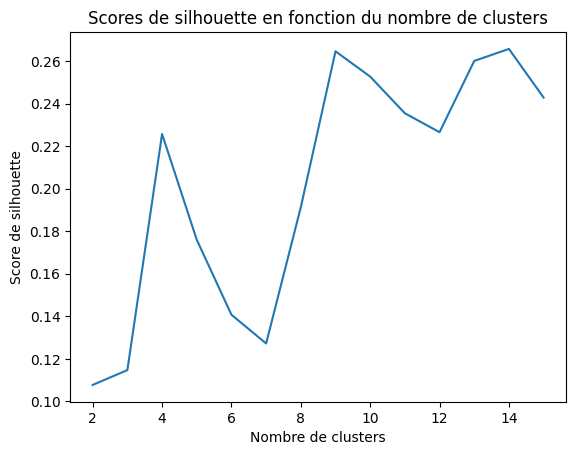

Le nombre optimal de clusters est : 14


In [103]:
X_std = X_std['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

In [108]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

Les 5 plus grands score de silhouette sont :
14 clusters pour 0.26575489335423474 score de silhouette
9 clusters pour 0.26463830414285067 score de silhouette
13 clusters pour 0.26010683651722044 score de silhouette
10 clusters pour 0.2527270713318005 score de silhouette
15 clusters pour 0.2428625626054935 score de silhouette


In [104]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 3241966.4349361514.
Iteration 1, inertia 1108842.0000000005.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 1946604.0514685686.
Iteration 1, inertia 1051277.980002432.
Iteration 2, inertia 1027446.6061182672.
Iteration 3, inertia 1026345.7970291211.
Converged at iteration 3: strict convergence.
3
Initialization complete
Iteration 0, inertia 1315788.9875450353.
Iteration 1, inertia 972941.051985624.
Iteration 2, inertia 967788.2545252248.
Iteration 3, inertia 956267.7672020136.
Iteration 4, inertia 948566.0801821757.
Iteration 5, inertia 948463.2788023471.
Converged at iteration 5: strict convergence.
4
Initialization complete
Iteration 0, inertia 1146714.200064421.
Iteration 1, inertia 925523.8214897173.
Iteration 2, inertia 912550.6182092516.
Iteration 3, inertia 905199.6464072283.
Iteration 4, inertia 903433.943019049.
Iteration 5, inertia 893938.3455201318.
Iteration 6, inertia 888714.024499

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

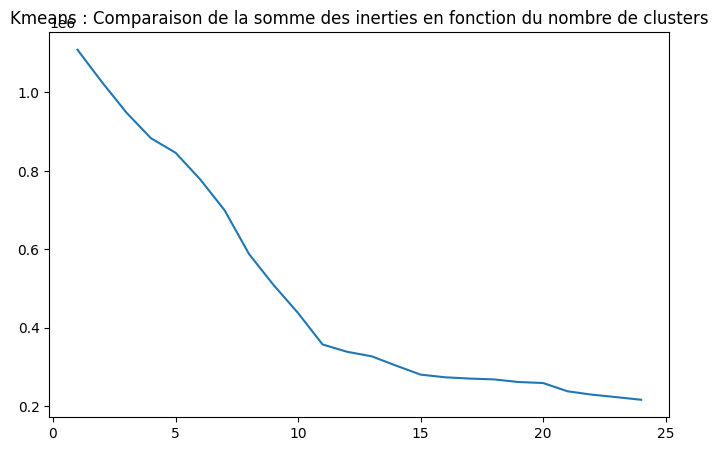

In [105]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [262]:
clusters_num = 4

kmeans_X_7 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_7)
kmeans_X_6 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_6)
kmeans_X_5 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_5)
kmeans_X_4 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_4)
kmeans_X_3 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_3)
kmeans_X_2 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_2)
kmeans_X_1 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_1)

Initialization complete
Iteration 0, inertia 1298057.8256855311.
Iteration 1, inertia 1149992.8558011092.
Iteration 2, inertia 1137949.291078147.
Iteration 3, inertia 1128597.4631593996.
Iteration 4, inertia 1122887.1942115342.
Iteration 5, inertia 1121710.6826966351.
Iteration 6, inertia 1121084.2845781425.
Iteration 7, inertia 1120693.4054786242.
Iteration 8, inertia 1120602.1686400115.
Iteration 9, inertia 1120565.331619706.
Iteration 10, inertia 1120553.4269204473.
Converged at iteration 10: center shift 4.798860331158723e-05 within tolerance 9.374999999997513e-05.
Initialization complete
Iteration 0, inertia 1224749.8328018046.
Iteration 1, inertia 1111289.2175830114.
Iteration 2, inertia 1111288.4782577113.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 1123797.1470793341.
Iteration 1, inertia 949787.9920593341.
Iteration 2, inertia 949034.9276971163.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, ine

# Compute ARI

In [263]:
adjusted_rand_score(kmeans_X_2.labels_, kmeans_X_1.predict(X_2))

0.8821333074985457

In [264]:
adjusted_rand_score(kmeans_X_3.labels_, kmeans_X_1.predict(X_3))

0.025032930564086106

In [265]:
ari0 = adjusted_rand_score(kmeans_X_1.labels_, kmeans_X_1.labels_)
ari1 = adjusted_rand_score(kmeans_X_2.labels_, kmeans_X_1.predict(X_2))
ari2 = adjusted_rand_score(kmeans_X_3.labels_, kmeans_X_1.predict(X_3))
ari3 = adjusted_rand_score(kmeans_X_4.labels_, kmeans_X_1.predict(X_4))
ari4 = adjusted_rand_score(kmeans_X_5.labels_, kmeans_X_1.predict(X_5))
ari5 = adjusted_rand_score(kmeans_X_6.labels_, kmeans_X_1.predict(X_6))
ari6 = adjusted_rand_score(kmeans_X_7.labels_, kmeans_X_1.predict(X_7))

In [266]:
scores = [ari0, ari1, ari2, ari3, ari4, ari5, ari6]
periodes = ['Période 0', 'Période 1', 'Période 2', 'Période 3', 'Période 4', 'Période 5', 'Période 6']

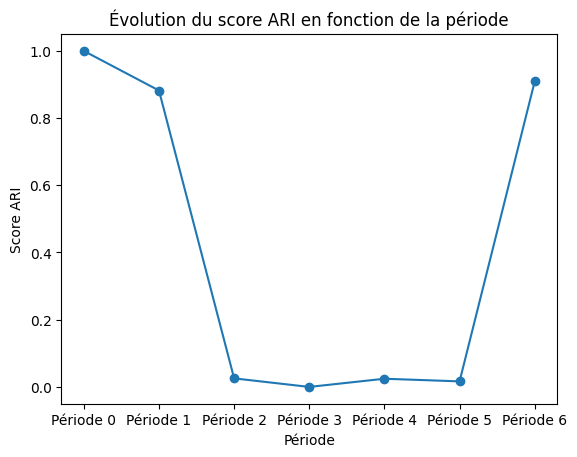

In [267]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()